# Regresión Lineal

**¿Qué es la regresión lineal?** 
La regresión lineal es un método estadístico utilizado para modelar la relación entre una variable dependiente y una o más variables independientes. Su objetivo principal es predecir el valor de la variable dependiente basándose en los valores de las variables independientes.

### Ejercicio 1: Coste de un incidente de seguridad

**Enunciado:** El ejercicio consiste en predecir el coste de un incidente de seguridad en base al número de equipos que se han visto afectados. Generaremos un conjunto de datos aleatorio que simule esta situación y aplicaremos la regresión lineal para realizar la predicción.

### 1. Generación de datos aleatorios
Para simular el escenario, generaremos un conjunto de datos aleatorio que represente el número de equipos afectados y el coste asociado a cada incidente de seguridad. Utilizaremos la biblioteca `numpy` para crear estos datos.

```python

In [12]:
import numpy as np

x = 2 * np.random.rand(100, 1)  # Número de equipos afectados (variable independiente)
y = 4 + 3 * x + np.random.randn(100, 1) # Coste del incidente de seguridad (variable dependiente) con algo de ruido aleatorio

print("La cantidad de datos generados es:", len(x))

La cantidad de datos generados es: 100


### 2. Visualización de los datos

Para entender mejor la relación entre el número de equipos afectados y el coste del incidente, podemos visualizar los datos generados utilizando un gráfico de dispersión. Esto nos permitirá observar si existe una tendencia lineal entre las dos variables.

```python

In [5]:
#Importamos la librería matplotlib para visualizar los datos

import matplotlib.pyplot as plt
%matplotlib inline


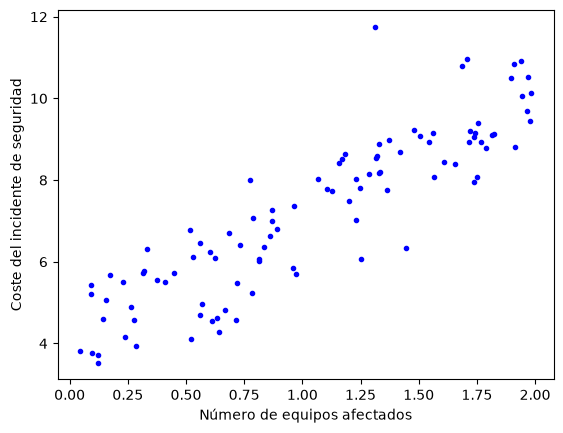

In [13]:
#Visualizamos los datos generados en un gráfico de dispersión para observar la relación entre el número de equipos afectados y el coste del incidente de seguridad.
plt.plot(x, y, "b.")
plt.xlabel("Número de equipos afectados")
plt.ylabel("Coste del incidente de seguridad")
plt.show()

### 3. Modificando el conjunto de datos



In [7]:
import pandas as pd

In [24]:
data = {"número_de_equipos_afectados": x.flatten(), "coste_del_incidente": y.flatten()}
df = pd.DataFrame(data)
df

,número_de_equipos_afectados,coste_del_incidente
0,1.816055,9.106592
1,1.738468,9.057812
2,1.251885,6.076178
3,1.914618,8.798019
4,1.330799,8.887563
...,...,...
95,1.655256,8.401811
96,0.604056,6.250184
97,1.285105,8.151626
98,1.787815,8.789760


In [25]:
# Arreglando los datos para que sean más consistentes y representativos de un escenario realista. 
df['número_de_equipos_afectados'] = (df['número_de_equipos_afectados'] * 1000).astype(int) # Para tener numeros reales de equipos afectados y los hacemos enteros.

# Ahora los datos del coste.
df['coste_del_incidente'] = (df['coste_del_incidente'] * 10000).astype(int) # Para tener numeros reales de coste y los hacemos enteros.
df

,número_de_equipos_afectados,coste_del_incidente
0,1816,91065
1,1738,90578
2,1251,60761
3,1914,87980
4,1330,88875
...,...,...
95,1655,84018
96,604,62501
97,1285,81516
98,1787,87897


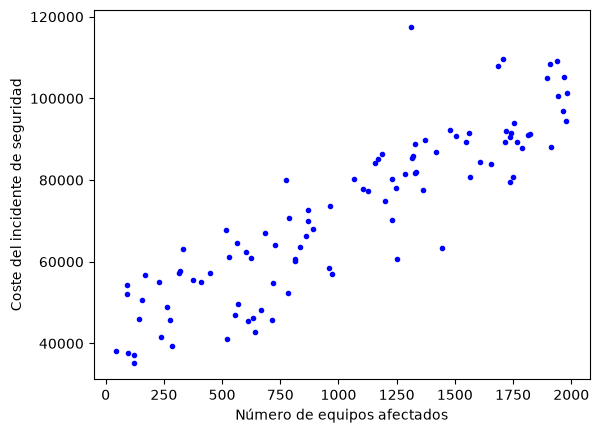

In [26]:
# Mostramos los datos finales en un gráfico de dispersión para observar la relación entre el número de equipos afectados y el coste del incidente de seguridad.

plt.plot(df['número_de_equipos_afectados'], df['coste_del_incidente'], "b.")
plt.xlabel("Número de equipos afectados")
plt.ylabel("Coste del incidente de seguridad")
plt.show()

### 4. Construyendo el modelo de regresión lineal

In [27]:
# Importamos la librería de scikit-learn para construir el modelo de regresión lineal

from sklearn.linear_model import LinearRegression

In [30]:
# Construyendo el modelo de regresión lineal
lin_reg = LinearRegression()

# Entrenamos el modelo con los datos generados
lin_reg.fit(df['número_de_equipos_afectados'].values.reshape(-1, 1), df['coste_del_incidente'].values)

# df['número_de_equipos_afectados'].values.reshape(-1, 1) es necesario para convertir la columna en un array 2D, que es lo que espera el método fit() de scikit-learn.
# df['coste_del_incidente'].values es un array 1D que contiene los valores de la variable dependiente.

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[30.45]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.036e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[5837.23]


In [31]:
# Parámetro theta 0
lin_reg.intercept_

np.float64(40364.9649194778)

In [32]:
# Parámetro theta 1
lin_reg.coef_

array([30.45269554])

In [33]:
# Predicción para hallar el valor minimo y máximo del conjunto de datos para poder graficar la línea de regresión lineal.
x_min = df['número_de_equipos_afectados'].min()
x_max = df['número_de_equipos_afectados'].max()
y_train_pred = lin_reg.predict([[x_min], [x_max]])

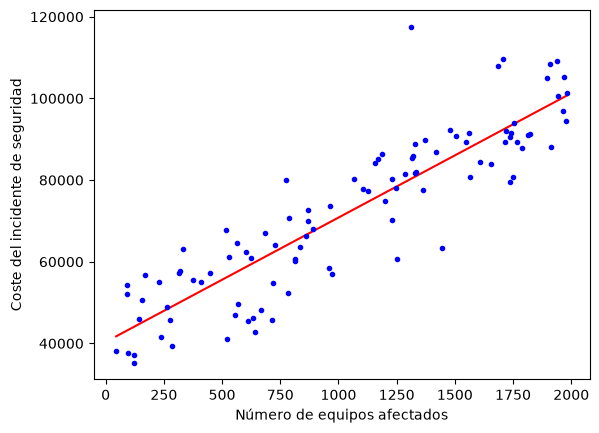

In [37]:
# Representación gráfica de la función hipótesis (línea de regresión lineal) junto con los datos de entrenamiento.
plt.plot((x_min, x_max), y_train_pred, "r-")
plt.plot(df['número_de_equipos_afectados'], df['coste_del_incidente'], "b.")
plt.xlabel("Número de equipos afectados")
plt.ylabel("Coste del incidente de seguridad")
plt.show()

### 5. Haciendo predicciones

Una vez que el modelo de regresión lineal ha sido entrenado, podemos utilizarlo para hacer predicciones sobre nuevos datos. Por ejemplo, podemos predecir el coste de un incidente de seguridad para un número específico de equipos afectados.

```python

In [42]:
x_new = np.array([1500])

# Predicción del coste del incidente de seguridad para un número específico de equipos afectados (por ejemplo, 1500).
y_new = lin_reg.predict(x_new.reshape(-1, 1))

print(f"El coste predicho del incidente de seguridad para 1500 equipos afectados es: {int(y_new[0])} MXN") 

El coste predicho del incidente de seguridad para 1500 equipos afectados es: 86044 MXN


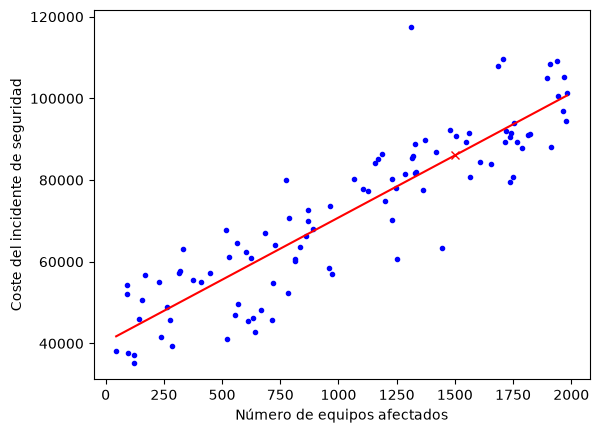

In [40]:
plt.plot(df['número_de_equipos_afectados'], df['coste_del_incidente'], "b.")
plt.plot((x_min, x_max), y_train_pred, "r-")
plt.plot(x_new, y_new, "rx")  # Punto de predicción
plt.xlabel("Número de equipos afectados")
plt.ylabel("Coste del incidente de seguridad")
plt.show()